In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración global de Seaborn
sns.set_theme(
style='whitegrid',
palette='muted',
font_scale=1.2
)
# Carga del dataset
df = pd.read_csv('cafeteria_universitaria_s8.csv')


NameError: name 'g' is not defined

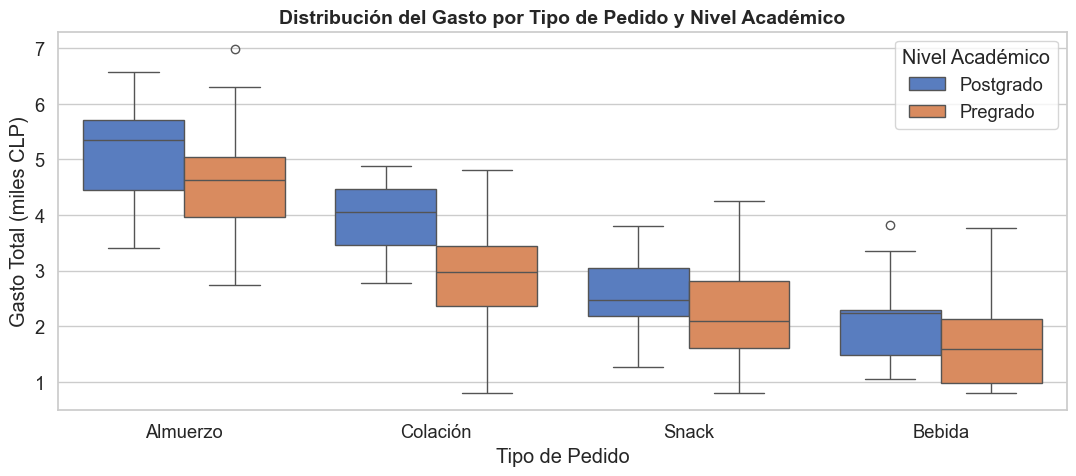

In [3]:
#Ejercicio 1

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df,
    x='tipo_pedido',
    y='gasto_total',
    hue='nivel_academico',
    palette='muted',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
    ax=ax
)

ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')

plt.tight_layout()
g.savefig('desafio_pairplot.svg', bbox_inches='tight')
g.savefig('desafio_pairplot.pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', dpi=300, bbox_inches='tight') 
plt.show()

# Preguntas de Análisis
# Responda las siguientes preguntas con base en el gráfico generado. Cada respuesta debe
# incluir evidencia visual específica (valores aproximados, posición de la mediana, presencia
# de outliers, etc.):
# 1. ¿Qué tipo de pedido presenta la mayor variabilidad en el gasto total? Justifique
# utilizando el IQR visual.
# Respuesta: El almuerzo.
# 2. ¿Se observan outliers en alguna categoría? Si es así, ¿en qué tipo de pedido y nivel
# académico aparecen? 
# Respuesta: Si, en almuerzo y bebida, 7 y 3.9.
# 3. ¿Existe una diferencia sistemática en el gasto entre estudiantes de Pregrado y
# Postgrado? ¿En qué categorías es más evidente? 
# Respuesta:Los de postgrado gastan más y se evidencia en Colación.

In [ ]:
#Ejercicio 2
fig, ax = plt.subplots(figsize=(11, 5))

sns.violinplot(
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='quartile',
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax,   
)

ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')

plt.tight_layout()
g.savefig('desafio_pairplot.svg', bbox_inches='tight')
g.savefig('desafio_pairplot.pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', dpi=300, bbox_inches='tight') 
plt.show()

# Preguntas de Análisis
# 1. ¿En qué turno es mayor el tiempo de espera mediano? ¿Esto tiene sentido desde una
# perspectiva operacional?
# Respuesta: En el turno de la tarde, porque es la hora de almuerzos.
# 2. ¿Las distribuciones del tiempo de espera son simétricas o presentan asimetría? ¿Hacia
# qué lado?
# Respuesta: Asimetria hacia el lado derecho.
# 3. Compare boxplot vs. violinplot para los mismos datos. ¿Qué información adicional
# entrega el violinplot que el boxplot no muestra?
# errada
# Respuesta: Permite detectar curvas que el boxplot no muestra.

In [ ]:
#Ejercicio 3

# Paso 1: Seleccionar solo columnas numéricas
num_cols = df.select_dtypes(include=['number'])
print('Variables numéricas:', list(num_cols.columns))
# Paso 2: Calcular la matriz de correlación de Pearson
corr_matrix = num_cols.corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))
# Paso 3: Visualizar como heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
data=corr_matrix,
annot=True,
fmt='.2f',
cmap='coolwarm',
vmin=1,
vmax=1,
linewidths=0.5,
linecolor='white',
square=True,
ax=ax
)    
ax.set_title('Matriz de Correlación de Pearson — Variables Numéricas',
fontsize=13, fontweight='bold')
plt.tight_layout()
g.savefig('desafio_pairplot.svg', bbox_inches='tight')
g.savefig('desafio_pairplot.pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', dpi=300, bbox_inches='tight') 
plt.show()

# Preguntas de Análisis
# 1. ¿Cuál es el par de variables con mayor correlación positiva? Indique el valor exacto y
# proponga una explicación causal plausible.
# Respuesta: El gasto_total y tiempo_espera_min tienen la mayor correlación positiva.
# 2. ¿Existe correlación negativa entre tiempo_espera_min y calificacion_servicio? ¿Cuál es
# su valor? ¿Le parece razonable desde el punto de vista operacional?
# Respuesta: Si existe, tienen -0.07 y -0.16.
# 3. ¿Qué variable numérica tiene la menor correlación promedio con el resto? ¿Qué
# implica esto para el análisis?
# Respuesta: propina_porcentaje tiene valores cercanos a 0 con casi todas las variables.

In [ ]:
#Ejercicio 4

sns.set_theme(style='whitegrid', font_scale=1.0)

g = sns.FacetGrid(
    df,
    col='turno',
    row='facultad',
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ciencias', 'Ingeniería', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida']
)

g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(col_template='Turno: {col_name}', row_template='{row_name}')

g.figure.suptitle(
    'Gasto por Tipo de Pedido · Facultad y Turno',
    y=1.02, fontsize=13, fontweight='bold'
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('desafio_pairplot.svg', bbox_inches='tight')
g.savefig('desafio_pairplot.pdf', bbox_inches='tight') 
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

# Preguntas de Análisis
# 1. ¿Qué combinación turno–facultad presenta el mayor gasto mediano en almuerzo? ¿Y
# el menor? 
# Respuesta: La combinación turno tarde en la facultad de ciencias y el menor el turno tarde en la facultad de humanidades.
# 2. ¿El patrón de gasto por turno es consistente entre las cuatro facultades, o existen
# diferencias notables? Describa al menos un caso particular. 
# Respuesta: En ciencias e ingeniería el gasto más alto es en el almuerzo en la tarde y en economia es en la noche.
# 3. ¿Cuál es la ventaja del FacetGrid sobre generar los mismos gráficos manualmente con
# subplots? Fundamente su respuesta.
# Respuesta: Comparar varios grupos al mismo tiempo de forma ordenada, se organiza todo en filas y columnas.

In [ ]:
#Ejercicio 5
# Seleccionar variables numéricas de interés
vars_plot = ['gasto_total', 'tiempo_espera_min',
'calificacion_servicio', 'propina_porcentaje']
g = sns.pairplot(
df[vars_plot + ['turno']],
hue='turno',
hue_order=['Mañana', 'Tarde', 'Noche'],
diag_kind='kde',
plot_kws={'alpha': 0.5},
palette='muted'
)
g.figure.suptitle(
'Relaciones Bivariadas por Turno de Atención',
y=1.02, fontsize=14, fontweight='bold'
)

g.savefig('desafio_pairplot.pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', dpi=300, bbox_inches='tight') 
g.savefig('desafio_pairplot.svg', bbox_inches='tight') # SVG = calidad vectorial
plt.show()